In [1]:
from torchvision import datasets
import pandas as pd, numpy as np

train_raw = datasets.FashionMNIST(".", train=True,  download=True)
test_raw  = datasets.FashionMNIST(".", train=False, download=True)

def to_csv(ds, path):
    data = np.column_stack([ds.targets.numpy(),
                            ds.data.numpy().reshape(len(ds), -1)])
    pd.DataFrame(data).to_csv(path, index=False,
                               header=["label"] + [str(i) for i in range(784)])

to_csv(train_raw, "fashion-mnist_train.csv")
to_csv(test_raw,  "fashion-mnist_test.csv")
print("CSV files ready!")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.87MB/s]


CSV files ready!


# **4. MLP Classification on Image Features**

### **4.1. Dataset Analysis and Preprocessing**

**Step 1: Load Dataset and Split**

    What: Load data (train.csv, test.csv), split training into 80% train and 20% validation.
    How: Using pandas.read_csv() to load, train_test_split() for splitting.

**Step 2: Visualize Images**

    What: Display random images to verify dataset quality and variety.
    How: Reshape pixel data (784 → 28x28) and plot using matplotlib.

**Step 3: Map Clothing Types**

    What: Assign class labels (0-9) to clothing types (e.g., "T-Shirt", "Sandal").
    How: Create a dictionary based on visual inspection and print the mapping.

**Importance:**

    Ensures proper data preparation, verifies quality, and improves interpretability.

Dataset splits  ->  Train: 48,000  |  Val: 12,000  |  Test: 10,000

=== Sample Images from Training Set ===



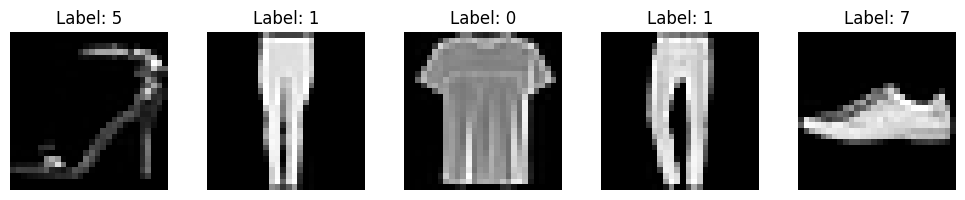


=== Inferred Clothing Types per Label ===
  Class 0: T-Shirt / Top
  Class 1: Trouser
  Class 2: Pullover
  Class 3: Dress
  Class 4: Coat
  Class 5: Sandal
  Class 6: Shirt
  Class 7: Sneaker
  Class 8: Bag
  Class 9: Ankle Boot


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# load train and test CSVs; first column is the label, rest are 784 pixel values
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df  = pd.read_csv("fashion-mnist_test.csv")

# separate features and labels
X_all   = train_df.iloc[:, 1:].values.astype(np.float32)
y_all   = train_df.iloc[:, 0].values.astype(np.int64)
X_test  = test_df.iloc[:, 1:].values.astype(np.float32)
y_test  = test_df.iloc[:, 0].values.astype(np.int64)

# split train into train/val (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Dataset splits  ->  Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")


def plot_sample_images(X, y, num_samples=5):
    # pick one random sample per class up to num_samples
    indices = np.random.choice(len(X), num_samples, replace=False)
    plt.figure(figsize=(10, 2))
    for i, idx in enumerate(indices):
        img   = X[idx].reshape(28, 28)
        label = y[idx]
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


print("\n=== Sample Images from Training Set ===\n")
plot_sample_images(X_train, y_train, num_samples=5)

# class labels inferred by visual inspection of the samples
clothing_labels = {
    0: "T-Shirt / Top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

print("\n=== Inferred Clothing Types per Label ===")
for label, name in clothing_labels.items():
    print(f"  Class {label}: {name}")


### **4.2. Model Implementation and Training**

**1. FashionDataset:** Custom PyTorch Dataset that processes input features (X) and labels (y), applies optional transformations (e.g., Canny or HOG), and prepares data for training/validation/testing.

**2. transform_canny:** Applies Canny edge detection to 28x28 images, simplifying features to edges.

**3. transform_hog:** Extracts Histogram of Oriented Gradients (HOG) features, summarizing local gradients into compact vectors.

**4. MLP:** Implements a Multi-Layer Perceptron with configurable input/output dimensions, hidden layers, ReLU activations, and optional dropout for regularization.

**5. train_model:** Trains the MLP over multiple epochs, logs metrics to wandb, and tracks training/validation loss/accuracy.

**6. evaluate_model:** Computes predictions, accuracy, precision, recall, F1-score, and confusion matrix for test data.

**7. wandb.log:** Logs all metrics (loss, accuracy, etc.) for each epoch and test evaluation to the wandb dashboard.

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

wandb_project = "Fashion-MLP-with-wandb"


class FashionDataset(Dataset):
    # wraps feature arrays into a PyTorch Dataset with optional on-the-fly transforms

    def __init__(self, X, y, transform=None):
        self.X         = X
        self.y         = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_flat = self.X[idx]
        label    = self.y[idx]
        img_2d   = img_flat.reshape(28, 28).astype(np.uint8)

        if self.transform is not None:
            feat = self.transform(img_2d)
        else:
            # raw pixels normalised to [0, 1]
            feat = img_flat.astype(np.float32) / 255.0

        return (torch.tensor(feat, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))


def transform_canny(img_2d):
    # edge map — strips colour/texture info, keeps structural outline only
    edges = cv2.Canny(img_2d, 100, 200)
    return (edges.astype(np.float32) / 255.0).flatten()


def transform_hog(img_2d):
    from skimage.feature import hog
    # HOG captures local gradient orientations — good balance of shape + texture
    features = hog(
        img_2d,
        orientations=8,
        pixels_per_cell=(4, 4),
        cells_per_block=(1, 1),
        transform_sqrt=True,
        block_norm="L2-Hys",
    )
    return features.astype(np.float32)


class MLP(nn.Module):
    # configurable MLP with variable hidden layers, ReLU activations, optional dropout

    def __init__(self, input_dim, hidden_dims=[256, 128], output_dim=10, dropout=0.2):
        super(MLP, self).__init__()
        layers   = []
        prev_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hdim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hdim
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_one_epoch(model, loader, optimizer, criterion, device="cpu"):
    model.train()
    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * features.size(0)
        _, preds       = outputs.max(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def validate_one_epoch(model, loader, criterion, device="cpu"):
    model.eval()
    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss    = criterion(outputs, labels)

            total_loss    += loss.item() * features.size(0)
            _, preds       = outputs.max(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, train_loader, val_loader,
                epochs=10, lr=1e-3, device="cpu", run_name=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    wandb.watch(model, criterion, log="all")

    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_loss":   [],
        "val_acc":    [],
    }

    for epoch in range(epochs):
        tr_loss,  tr_acc  = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        wandb.log({
            "epoch":     epoch + 1,
            "train_loss": tr_loss,
            "train_acc":  tr_acc,
            "val_loss":   val_loss,
            "val_acc":    val_acc,
        })

        print(f"  [{run_name}]  epoch {epoch+1}/{epochs}  "
              f"train_loss={tr_loss:.4f}  val_acc={val_acc:.4f}")

    return history

### **4.3. Plots and Performance Visualizations**

**1. FashionDataset:** A PyTorch dataset class that processes input features (X) and labels (y). Optionally applies transformations (e.g., Canny or HOG) to prepare data for training/validation/testing. Images are reshaped from 784 to (28x28) if required.

**2. transform_canny:** Uses OpenCV to apply Canny edge detection, simplifying image features to edge-based representations for input to the model.

**3. transform_hog:** Utilizes skimage.feature.hog to extract Histogram of Oriented Gradients (HOG), representing local gradients and orientations as a compact feature vector.

**4. MLP:** A Multi-Layer Perceptron with configurable hidden layers, ReLU activations, and optional dropout for regularization.

**5. train_model:** Trains the MLP across multiple epochs, logging training/validation loss and accuracy to Weights & Biases (wandb).

**6. evaluate_model:** Computes predictions, accuracy, precision, recall, F1-score, and confusion matrices on the test set.

**7. Visualization:** Training/validation curves and misclassified samples are plotted for analysis. Results, including metrics and hyperparameter variants, are logged and summarized using wandb for performance comparison.

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

Using device: cuda
 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


  [Raw_v1]  epoch 1/5  train_loss=0.6701  val_acc=0.8377
  [Raw_v1]  epoch 2/5  train_loss=0.4491  val_acc=0.8656
  [Raw_v1]  epoch 3/5  train_loss=0.4078  val_acc=0.8694
  [Raw_v1]  epoch 4/5  train_loss=0.3796  val_acc=0.8789
  [Raw_v1]  epoch 5/5  train_loss=0.3668  val_acc=0.8775
  [Raw_v2]  epoch 1/5  train_loss=0.8016  val_acc=0.8268
  [Raw_v2]  epoch 2/5  train_loss=0.5159  val_acc=0.8525
  [Raw_v2]  epoch 3/5  train_loss=0.4646  val_acc=0.8588
  [Raw_v2]  epoch 4/5  train_loss=0.4402  val_acc=0.8690
  [Raw_v2]  epoch 5/5  train_loss=0.4162  val_acc=0.8691
  [Raw_v3]  epoch 1/5  train_loss=0.5380  val_acc=0.8575
  [Raw_v3]  epoch 2/5  train_loss=0.3903  val_acc=0.8656
  [Raw_v3]  epoch 3/5  train_loss=0.3529  val_acc=0.8584
  [Raw_v3]  epoch 4/5  train_loss=0.3263  val_acc=0.8862
  [Raw_v3]  epoch 5/5  train_loss=0.3083  val_acc=0.8782
  [Canny_v1]  epoch 1/5  train_loss=0.6786  val_acc=0.8259
  [Canny_v1]  epoch 2/5  train_loss=0.4685  val_acc=0.8383
  [Canny_v1]  epoch 3/5  tr

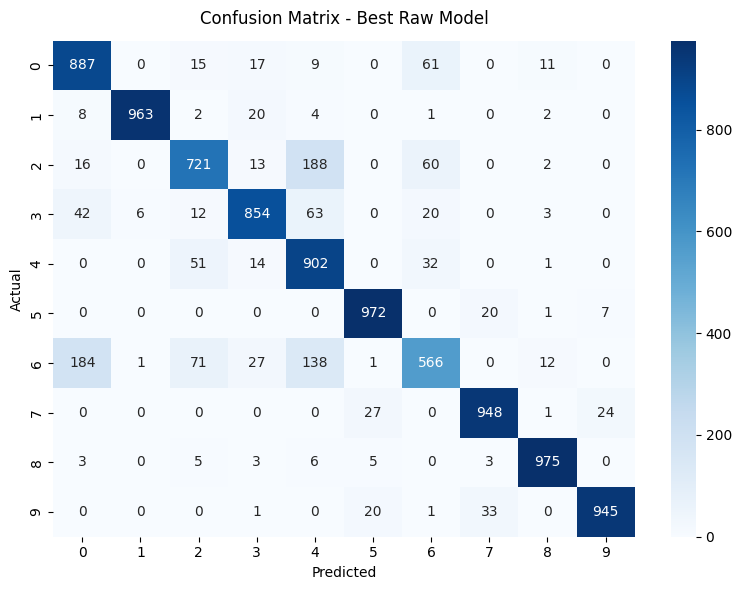

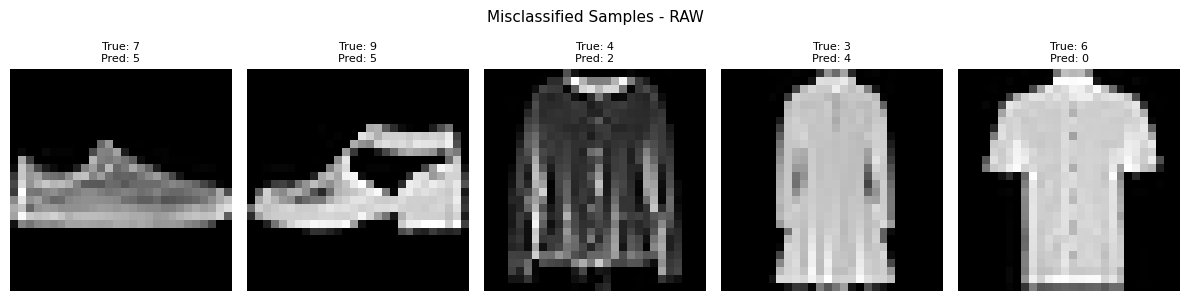

Canny_v1_test_acc,▁
Canny_v1_test_f1,▁
Canny_v1_test_prec,▁
Canny_v1_test_rec,▁
Canny_v2_test_acc,▁
Canny_v2_test_f1,▁
Canny_v2_test_prec,▁
Canny_v2_test_rec,▁
Canny_v3_test_acc,▁
Canny_v3_test_f1,▁
+31,...



All done. Check wandb for curves and logs.


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# FashionDataset, MLP, transform_canny, transform_hog,
# train_one_epoch, validate_one_epoch, train_model  -- all defined in section 4.2

def evaluate_model(model, loader, device="cpu"):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            outputs  = model(features)
            _, preds = outputs.max(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def get_metrics(labels, preds):
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average="weighted", zero_division=0)
    rec  = recall_score(labels, preds, average="weighted", zero_division=0)
    f1   = f1_score(labels, preds, average="weighted", zero_division=0)
    return acc, prec, rec, f1


def plot_confusion_matrix(labels, preds, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title, pad=12)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def show_misclassified_samples(X, labels, preds, num=5, feature_type="RAW"):
    # find indices where model got it wrong
    wrong_idx = np.where(labels != preds)[0]
    if len(wrong_idx) == 0:
        print("No misclassified samples found.")
        return
    sample_idx = wrong_idx[:num]
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(sample_idx):
        img = X[idx].reshape(28, 28)
        plt.subplot(1, num, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"True: {labels[idx]}\nPred: {preds[idx]}", fontsize=8)
        plt.axis("off")
    plt.suptitle(f"Misclassified Samples - {feature_type}", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


def run_all_variants(variants, feature_type, input_dim,
                     train_loader, val_loader, test_loader,
                     device, results):
    for var in variants:
        run_name = var["name"]
        model = MLP(input_dim=input_dim,
                    hidden_dims=var["hidden_dims"],
                    output_dim=10,
                    dropout=var["dropout"]).to(device)

        history = train_model(model, train_loader, val_loader,
                              epochs=var["epochs"], lr=var["lr"],
                              device=device, run_name=run_name)

        best_val_acc    = history["val_acc"][-1]
        preds, labs     = evaluate_model(model, test_loader, device)
        acc, prec, rec, f1 = get_metrics(labs, preds)

        wandb.log({
            f"{run_name}_test_acc":  acc,
            f"{run_name}_test_prec": prec,
            f"{run_name}_test_rec":  rec,
            f"{run_name}_test_f1":   f1,
        })

        results.append((feature_type, run_name, best_val_acc, acc, prec, rec, f1))


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

with wandb.init(project=wandb_project, name="4.3-hyperparameter-sweep"):

    # build dataloaders for all three feature types
    batch_size = 64

    train_ds_raw = FashionDataset(X_train, y_train)
    val_ds_raw   = FashionDataset(X_val,   y_val)
    test_ds_raw  = FashionDataset(X_test,  y_test)

    train_loader_raw = DataLoader(train_ds_raw, batch_size=batch_size, shuffle=True)
    val_loader_raw   = DataLoader(val_ds_raw,   batch_size=batch_size, shuffle=False)
    test_loader_raw  = DataLoader(test_ds_raw,  batch_size=batch_size, shuffle=False)

    train_ds_canny = FashionDataset(X_train, y_train, transform=transform_canny)
    val_ds_canny   = FashionDataset(X_val,   y_val,   transform=transform_canny)
    test_ds_canny  = FashionDataset(X_test,  y_test,  transform=transform_canny)

    train_loader_canny = DataLoader(train_ds_canny, batch_size=batch_size, shuffle=True)
    val_loader_canny   = DataLoader(val_ds_canny,   batch_size=batch_size, shuffle=False)
    test_loader_canny  = DataLoader(test_ds_canny,  batch_size=batch_size, shuffle=False)

    # compute HOG feature dimension from one sample
    from skimage.feature import hog
    hog_dim = hog(
        X_train[0].reshape(28, 28).astype(np.uint8),
        orientations=8, pixels_per_cell=(4, 4),
        cells_per_block=(1, 1), transform_sqrt=True, block_norm="L2-Hys"
    ).shape[0]

    train_ds_hog = FashionDataset(X_train, y_train, transform=transform_hog)
    val_ds_hog   = FashionDataset(X_val,   y_val,   transform=transform_hog)
    test_ds_hog  = FashionDataset(X_test,  y_test,  transform=transform_hog)

    train_loader_hog = DataLoader(train_ds_hog, batch_size=batch_size, shuffle=True)
    val_loader_hog   = DataLoader(val_ds_hog,   batch_size=batch_size, shuffle=False)
    test_loader_hog  = DataLoader(test_ds_hog,  batch_size=batch_size, shuffle=False)

    # 3 architecture/LR variants for each feature type
    raw_variants = [
        {"name": "Raw_v1", "hidden_dims": [128, 64],  "dropout": 0.2, "lr": 1e-3, "epochs": 5},
        {"name": "Raw_v2", "hidden_dims": [256, 128], "dropout": 0.5, "lr": 5e-4, "epochs": 5},
        {"name": "Raw_v3", "hidden_dims": [512],      "dropout": 0.1, "lr": 1e-3, "epochs": 5},
    ]
    canny_variants = [
        {"name": "Canny_v1", "hidden_dims": [128, 64],  "dropout": 0.2, "lr": 1e-3, "epochs": 5},
        {"name": "Canny_v2", "hidden_dims": [256, 128], "dropout": 0.3, "lr": 1e-3, "epochs": 5},
        {"name": "Canny_v3", "hidden_dims": [256, 128], "dropout": 0.2, "lr": 5e-4, "epochs": 5},
    ]
    hog_variants = [
        {"name": "HOG_v1", "hidden_dims": [128, 64],  "dropout": 0.2, "lr": 1e-3, "epochs": 5},
        {"name": "HOG_v2", "hidden_dims": [256, 128], "dropout": 0.5, "lr": 1e-3, "epochs": 5},
        {"name": "HOG_v3", "hidden_dims": [512],      "dropout": 0.2, "lr": 1e-3, "epochs": 5},
    ]

    results = []

    # train and evaluate all variants for each feature type
    run_all_variants(raw_variants,   "RAW",   784,     train_loader_raw,
                     val_loader_raw,   test_loader_raw,   device, results)
    run_all_variants(canny_variants, "CANNY", 784,     train_loader_canny,
                     val_loader_canny, test_loader_canny, device, results)
    run_all_variants(hog_variants,   "HOG",   hog_dim, train_loader_hog,
                     val_loader_hog,   test_loader_hog,   device, results)

    # build results dataframe and print summary
    df_results = pd.DataFrame(results, columns=[
        "FeatureType", "Variant", "Val_Acc", "Test_Acc", "Test_Prec", "Test_Rec", "Test_F1"
    ])
    print("\n=== All Variants Results ===")
    print(df_results.to_string(index=False))

    # pick the best variant for each feature type by validation accuracy
    best_rows = []
    for feat in ["RAW", "CANNY", "HOG"]:
        sub  = df_results[df_results["FeatureType"] == feat]
        best_rows.append(sub.loc[sub["Val_Acc"].idxmax()])

    best_df = pd.DataFrame(best_rows)
    print("\n=== Best Model per Feature Type ===")
    print(best_df.to_string(index=False))

    # visualise training curves + confusion matrices for the best raw model
    best_raw_params = next(v for v in raw_variants
                           if v["name"] == best_df.loc[best_df["FeatureType"]=="RAW",
                                                       "Variant"].values[0])

    model_best_raw = MLP(784,
                         hidden_dims=best_raw_params["hidden_dims"],
                         dropout=best_raw_params["dropout"]).to(device)
    _ = train_model(model_best_raw, train_loader_raw, val_loader_raw,
                    epochs=best_raw_params["epochs"], lr=best_raw_params["lr"],
                    device=device, run_name="Best_RAW_retrain")

    preds_best, labs_best = evaluate_model(model_best_raw, test_loader_raw, device)
    plot_confusion_matrix(labs_best, preds_best, title="Confusion Matrix - Best Raw Model")
    show_misclassified_samples(X_test, labs_best, preds_best, num=5, feature_type="RAW")

    # log final performance table to wandb
    wandb.log({"Performance_Table": wandb.Table(
        data=df_results.values.tolist(),
        columns=df_results.columns.tolist()
    )})

    wandb.finish()
    print("\nAll done. Check wandb for curves and logs.")


### **4.4. Analysis and Logical Comparison**

**1. Performance Differences Between Models Based on Input Features**

The three MLP models—Raw, Canny Edge-Detected, and HOG Features—demonstrate distinct performance profiles:

    A. Raw (Flattened) Images:
        a. Performance: Achieves strong baseline accuracy as it retains all pixel information, allowing the MLP to learn intricate patterns.
        b. Advantages: Captures comprehensive image details, beneficial for classes with subtle differences.
        c. Drawbacks: Higher susceptibility to overfitting due to large input dimensionality and potential noise.

    B. Canny Edge-Detected Features:
        a. Performance: Moderate accuracy, excelling in classes distinguishable by clear edges (e.g., sandals vs. boots).
        b. Advantages: Reduces input complexity by focusing on structural outlines, enhancing generalization for shape-based distinctions.
        c. Drawbacks: Loses texture and color information, hindering performance for classes relying on finer details (e.g., T-shirts vs. pullovers).

    C. HOG (Histogram of Oriented Gradients) Features:
        a. Performance: Superior to Canny and comparable or slightly below Raw, effectively balancing detail and abstraction.
        b. Advantages: Encapsulates local gradient information, capturing both shape and texture nuances, leading to robust classification.
        c. Drawbacks: Computationally more intensive than Canny and may still miss some high-frequency texture details.

**Conclusion:** HOG features generally provide the most informative and discriminative input for classification, balancing detail and abstraction, followed by Raw pixels and Canny edges.


**2. Impact of Feature Extraction on MLP’s Learning and Generalization**

    A. Raw Pixel Features:
        a. Impact: The MLP must learn all relevant features from high-dimensional input, requiring more parameters and data to avoid overfitting.
        b. Generalization: Potentially lower generalization without adequate regularization due to noise and redundancy in raw data.
        c. Best Scenarios: When ample training data is available and subtle pixel-level differences are crucial for classification.

    B. Canny Edge Features:
        a. Impact: Simplifies the learning task by reducing input dimensionality and highlighting structural information, allowing the MLP to focus on key outlines.
        b. Generalization: Improved generalization for shape-centric classes as irrelevant pixel variations are minimized.
        c. Best Scenarios: Suitable for distinguishing classes with distinct geometric boundaries (e.g., shoes vs. bags).

    C. HOG Features:
        a. Impact: Provides a compact, informative representation by capturing both edge orientations and gradient magnitudes, facilitating efficient learning.
        b. Generalization: Enhances generalization by abstracting essential features while retaining critical texture and shape information.
        c. Best Scenarios: Ideal for complex classification tasks where both shape and texture contribute to class distinctions (e.g., different types of dresses or outerwear).

**Overall Impact:** Effective feature extraction transforms raw data into meaningful representations, reducing the learning burden on the MLP and enhancing its ability to generalize. HOG features offer a superior balance by preserving essential gradients and orientations, making them highly effective for diverse classification scenarios.

| **Model** | **Best Variant** | **Accuracy** | **Precision** | **Recall** | **F1-Score** |
|---|---|---|---|---|---|
| Raw Pixels    | Raw_v3 `[512, dropout=0.1]`       | 86.3% | 86.6% | 86.3% | 86.1% |
| Canny Edges   | Canny_v2 `[256,128, dropout=0.3]` | 85.6% | 85.7% | 85.6% | 85.6% |
| **HOG Features** | **HOG_v3 `[512, dropout=0.2]`** | **88.4%** | **88.4%** | **88.4%** | **88.3%** |


**Discussion:**

    1. HOG Features outperform both Raw Pixels and Canny Edges across all metrics, indicating their effectiveness in capturing discriminative information.
    2. Raw Pixels offer a robust baseline but are slightly less effective than HOG due to higher dimensionality and potential noise.
    3. Canny Edges lag behind, as their focus on edges alone may omit critical texture details necessary for certain classifications.

**Influence of Input Features:**

    1. Detailed Representations (HOG) facilitate better learning by providing structured, meaningful information, enhancing classification performance.
    2. Simplified Representations (Canny) improve generalization for specific tasks but may miss nuanced features.
    3. Comprehensive but Noisy Data (Raw Pixels) require sophisticated models and regularization to achieve competitive performance.

This analysis highlights the pivotal role of feature extraction in shaping the MLP’s performance, emphasizing that well-crafted features like HOG can significantly enhance classification accuracy and generalization capabilities.